# Convergence Analysis of Reinforcement Learning Training

This notebook analyzes the convergence behavior of a reinforcement learning agent trained to follow trajectories with a Panda robot arm. It evaluates performance on **seen** (training) and **unseen** (generalization) trajectories, identifies convergence points, and visualizes reward distributions.

## 1. Setup and Imports

In [461]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import re
from scipy.optimize import curve_fit

## 2. Load and Preprocess Data

Load the trajectory results from a CSV file. The `rewards` column is stored as a string representation of a list, so it is parsed into NumPy arrays. The first 3 reward values of each episode are discarded to avoid initial transient noise.

In [ ]:
# read csv file
ts = "09"
data_path = f"../../data/{ts}_all_trajectories_results.csv"
df = pd.read_csv(data_path)
df["rewards"] = df["rewards"].apply(ast.literal_eval)
# ignore first 3 elements
df["rewards"] = df["rewards"].apply(lambda x: np.array(x[3:], dtype=float))

## 3. Compute Mean Rewards

Calculate the mean reward for each row and extract the episode number from the model name using a regex pattern.

In [ ]:
# calculate mean reward
df["reward_mean"] = df["rewards"].apply( lambda x: np.mean(x[:]))
# extract episode number from model name
df["episodes"] = df["model"].str.extract(r"_ep_(\d+)").astype(int)

## 4. Group Rewards by Trajectory Type

Trajectories are split into three groups to evaluate both training performance and generalization:

- **Seen trajectories**: Trajectories used during training (`ah-square`, `ah-circle`, `h-square`, `h-triangle`, `h-circle`).
- **Unseen trajectories**: Trajectories **not** used during training, to test generalization (`ah-triangle`, `h-pentagon`, `ah-pentagon`).
- **All trajectories**: Combined set of seen and unseen.

For each group, the mean reward across trajectories is computed per episode.

In [465]:
# Compute mean reward for seen trajectories
seen_trajectories = ["ah-square", "ah-circle", "h-square", "h-triangle", "h-circle"]
df_seen = df[df["trajectory"].isin(seen_trajectories)]
df_seen = df_seen.sort_values(by="episodes")
df["mean_reward_seen"] = df_seen.groupby("episodes")["reward_mean"].transform("mean")
df_mean_seen = (
    df_seen.groupby("episodes")["reward_mean"]
    .mean()
    .reset_index()
    .rename(columns={"reward_mean": "mean_reward_seen"})
)
# Compute mean reward for unseen trajectories
unseen_trajectories = ["ah-triangle", "h-pentagon", "ah-pentagon"]
df_unseen = df[df["trajectory"].isin(unseen_trajectories)]
df_unseen = df_unseen.sort_values(by="episodes")
df["mean_reward_unseen"] = df_unseen.groupby("episodes")["reward_mean"].transform("mean")
df_mean_unseen = (
    df_unseen.groupby("episodes")["reward_mean"]
    .mean()
    .reset_index()
    .rename(columns={"reward_mean": "mean_reward_unseen"})
)
# Compute mean reward for all trajectories
trajectories = df["trajectory"].unique()
df_all = df[df["trajectory"].isin(trajectories)]
df_all = df_all.sort_values(by="episodes")
df["mean_reward_all"] = df_all.groupby("episodes")["reward_mean"].transform("mean")
df_mean_all = (
    df_all.groupby("episodes")["reward_mean"]
    .mean()
    .reset_index()
    .rename(columns={"reward_mean": "mean_reward_all"})
)
df_mean_seen

,episodes,mean_reward_seen
0,100,-3.510506
1,200,-4.429389
2,300,-1.105382
3,400,0.013084
4,500,-1.103245
...,...,...
747,74800,5.839098
748,74900,6.134385
749,75000,5.702596
750,75100,6.058080


## 5. Reward Curves per Trajectory

Plot the mean reward as a function of training episodes for each individual trajectory. This helps identify which trajectories the agent learns faster or struggles with.

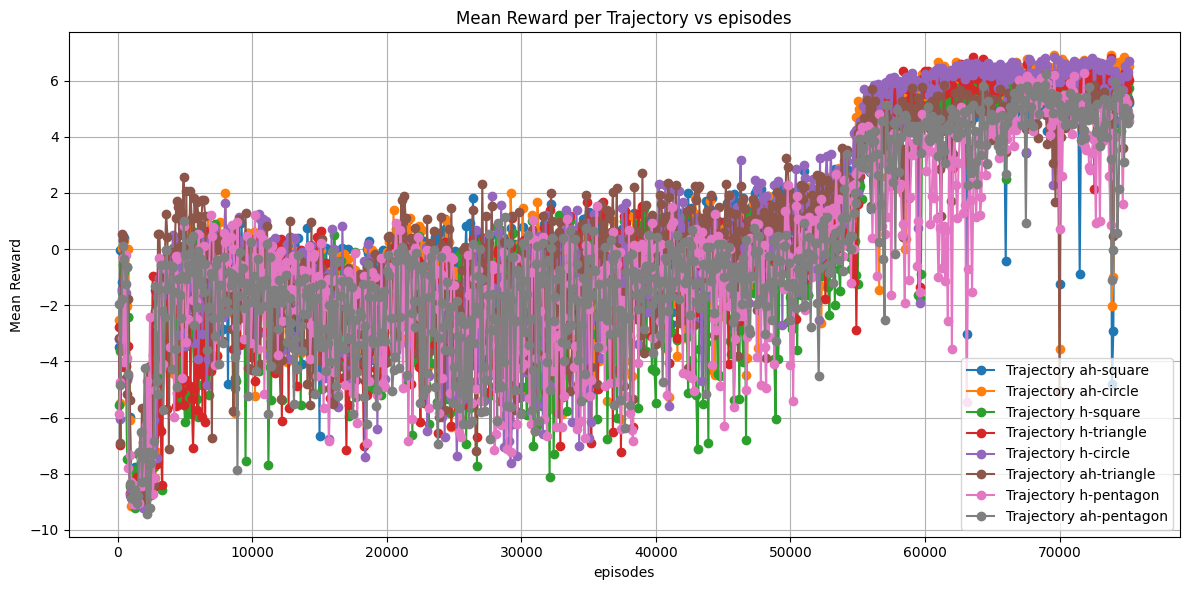

In [466]:
# Plot mean reward vs episodes for each trajectory
plt.figure(figsize=(12, 6))

for trajectory in df["trajectory"].unique():
    traj_data = df[df["trajectory"] == trajectory]
    traj_data = traj_data.sort_values(by="episodes")
    plt.plot(traj_data["episodes"], traj_data["reward_mean"], marker='o', label=f'Trajectory {trajectory}')

plt.xlabel("episodes")
plt.ylabel("Mean Reward")
plt.title("Mean Reward per Trajectory vs episodes")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Convergence Detection Method

The function `get_convergence_point` detects when training has converged using a **sliding window** approach on the smoothed reward curve:

1. The raw rewards are smoothed with a moving average.
2. Both episodes and rewards are normalized to [0, 1].
3. A window slides across the smoothed curve; convergence is detected when the **relative variation** (max − min) / mean within the window falls below a threshold.

The function also plots the raw data, smoothed curve, detected convergence point, and the best episode for reference.

In [ ]:
def get_convergence_point(data, 
                          convergence_threshold=0.1,
                          window_fraction=0.07,
                          type = "mean_reward_seen",
                          plot_label="Mean Reward with Delayed Exponential Fit",
                          best_ep = None):
    """ Computes the convergence point of the reward curve using a window-based method to avoid local minima or maxima.
    Args:
        data (pd.DataFrame): DataFrame containing the reward data and episode numbers.
        convergence_threshold (float): Threshold for determining convergence based on relative variation.
        window_fraction (float): Fraction of the data length to use as the window size for smoothing.
        type (str): Column name in the DataFrame to analyze (e.g., "mean_reward_seen").
        plot_label (str): Title for the plot.
        best_ep (int, optional): Episode number of the best performance to be marked on the plot.
    Returns:
        tuple: (convergence_episode, reward_at_convergence) where convergence_episode is the episode number at which convergence is detected, and reward_at_convergence is the reward value at that episode.
    """

    x = np.array(data["episodes"])
    reward = np.array(data[type])
    window_size = min(3, round(window_fraction * len(reward))) 

    reward_smoothed_raw = np.convolve(reward, np.ones(window_size)/window_size, mode='valid')
    x_smoothed = x[window_size-1:]


    reward_min = np.min(reward)
    reward_max = np.max(reward)
    x_min = np.min(x)
    x_max = np.max(x)
    
    x_norm = (x - x_min) / (x_max - x_min)
    reward_norm = (reward - reward_min) / (reward_max - reward_min)

    x_smoothed_norm = (x_smoothed - x_min) / (x_max - x_min)
    reward_smoothed_norm = (reward_smoothed_raw - reward_min) / (reward_max - reward_min)
    
    window_size_conv = max(3, round(len(reward_smoothed_raw) * window_fraction))

    # Method: dynamic window to avoid minimum or maximum locals
    convergence_step = x_smoothed_norm[-1] # default value
    convergence_id = -1
    for i in range(len(reward_smoothed_norm) - window_size_conv):
        window = reward_smoothed_norm[i:i + window_size_conv]
        window_mean = np.mean(window)
        window_min = np.min(window)
        window_max = np.max(window)
        
        if abs(window_mean) < 1e-6:
            continue
        
        # Relative variation: (max - min) / mean
        relative_variation = (window_max - window_min) / abs(window_mean)
        if relative_variation < convergence_threshold:
            convergence_step = x_smoothed_norm[i + window_size_conv // 2]
            convergence_id = i + window_size_conv // 2
            break

    convergence_episode = x_smoothed[convergence_id] if convergence_id >= 0 else x[-1]
    convergence_id_original = np.argmin(np.abs(x - convergence_episode))
    reward_at_convergence = reward[convergence_id_original]
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(x_norm, reward_norm, 'o', label='Raw Data', alpha=0.5, markersize=4)
    plt.plot(x_smoothed_norm, reward_smoothed_norm, '-', linewidth=2.5, 
             label=f'Smoothed Data (window={window_size})')
    if convergence_id >= 0:
        plt.axvline(convergence_step, color='r', linestyle='--', 
                    label=f'Convergence (ep {int(convergence_episode)})')
    if best_ep is not None:
        best_ep_norm = (best_ep - x_min) / (x_max - x_min)
        plt.axvline(best_ep_norm, color='purple', linestyle='--', 
                    label=f'Best Ep (ep {int(best_ep)})')
    
    # Show convergence window
    if convergence_id >= 0 and convergence_id >= window_size_conv//2 and \
       convergence_id + window_size_conv//2 < len(x_smoothed_norm):
        plt.axvspan(x_smoothed_norm[convergence_id - window_size_conv//2], 
                    x_smoothed_norm[convergence_id + window_size_conv//2],
                    alpha=0.2, color='green', label='Convergence window')
    
    plt.xlabel("Episodes (normalized)")
    plt.ylabel("Mean Reward (normalized)")
    plt.title(f"{plot_label}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    

    return (int(convergence_episode), reward_at_convergence)

## 7. Best Performing Episodes

Identify the episode with the highest mean reward for each trajectory group (seen, unseen, all). This serves as an upper-bound reference for performance comparison against the convergence point.

In [468]:
# Check step with the best mean reward acrross all trajectories
best_seen = df_mean_seen["mean_reward_seen"].idxmax()
best_unseen = df_mean_unseen["mean_reward_unseen"].idxmax()
best_all = df_mean_all["mean_reward_all"].idxmax()
best_ep_all = df_mean_all.loc[best_all, "episodes"]
best_ep_seen = df_mean_seen.loc[best_seen, "episodes"]
best_ep_unseen = df_mean_unseen.loc[best_unseen, "episodes"]

print(best_all, best_seen, best_unseen)
print(f"\nBest Mean Reward Episodes (of {df['episodes'].max()}):")
print(
    f"All Trajectories: Episode {best_ep_all}: "
    f"Mean Reward ALL {df_mean_all.loc[best_all, 'mean_reward_all']:.2f} - "
    f"Mean Reward SEEN {df_mean_seen.loc[df_mean_seen['episodes']==best_ep_all, 'mean_reward_seen'].item():.2f} - "
    f"Mean Reward UNSEEN {df_mean_unseen.loc[df_mean_unseen['episodes']==best_ep_all, 'mean_reward_unseen'].item():.2f}"
)

print(
    f"Seen Trajectories: Episode {best_ep_seen}: "
    f"Mean Reward ALL {df_mean_all.loc[df_mean_all['episodes']==best_ep_seen, 'mean_reward_all'].item():.2f} - "
    f"Mean Reward SEEN {df_mean_seen.loc[best_seen, 'mean_reward_seen']:.2f} - "
    f"Mean Reward UNSEEN {df_mean_unseen.loc[df_mean_unseen['episodes']==best_ep_seen, 'mean_reward_unseen'].item():.2f}"
)

print(
    f"Unseen Trajectories: Episode {best_ep_unseen}: "
    f"Mean Reward ALL {df_mean_all.loc[df_mean_all['episodes']==best_ep_unseen, 'mean_reward_all'].item():.2f} - "
    f"Mean Reward SEEN {df_mean_seen.loc[df_mean_seen['episodes']==best_ep_unseen, 'mean_reward_seen'].item():.2f} - "
    f"Mean Reward UNSEEN {df_mean_unseen.loc[best_unseen, 'mean_reward_unseen']:.2f}"
)

688 737 675

Best Mean Reward Episodes (of 75200):
All Trajectories: Episode 68900: Mean Reward ALL 6.08 - Mean Reward SEEN 6.25 - Mean Reward UNSEEN 5.80
Seen Trajectories: Episode 73800: Mean Reward ALL 5.17 - Mean Reward SEEN 6.46 - Mean Reward UNSEEN 3.02
Unseen Trajectories: Episode 67600: Mean Reward ALL 5.97 - Mean Reward SEEN 6.04 - Mean Reward UNSEEN 5.84


## 8. Convergence Analysis

Apply the convergence detection method to each trajectory group (seen, unseen, all). The plots show the normalized reward curve, the smoothed version, and the detected convergence episode alongside the best episode.

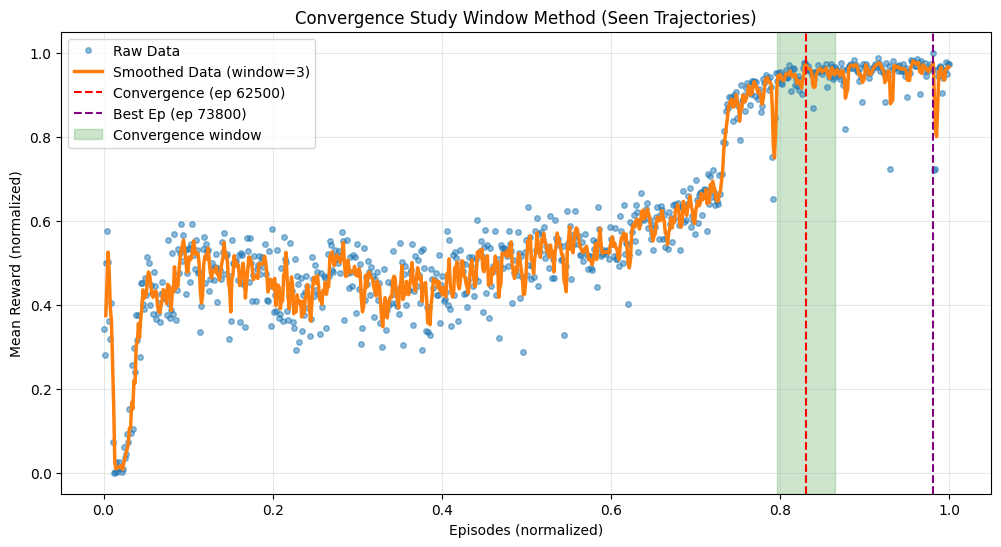

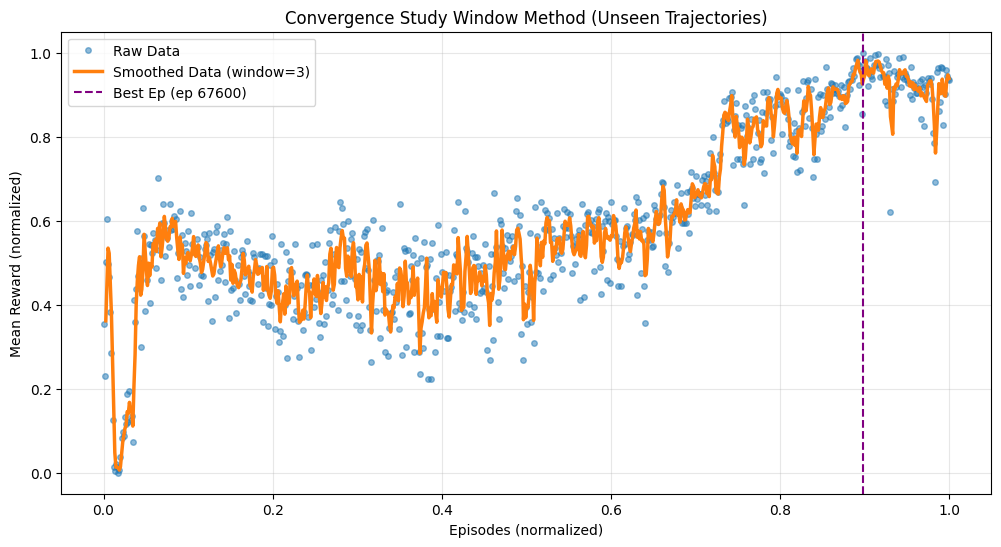

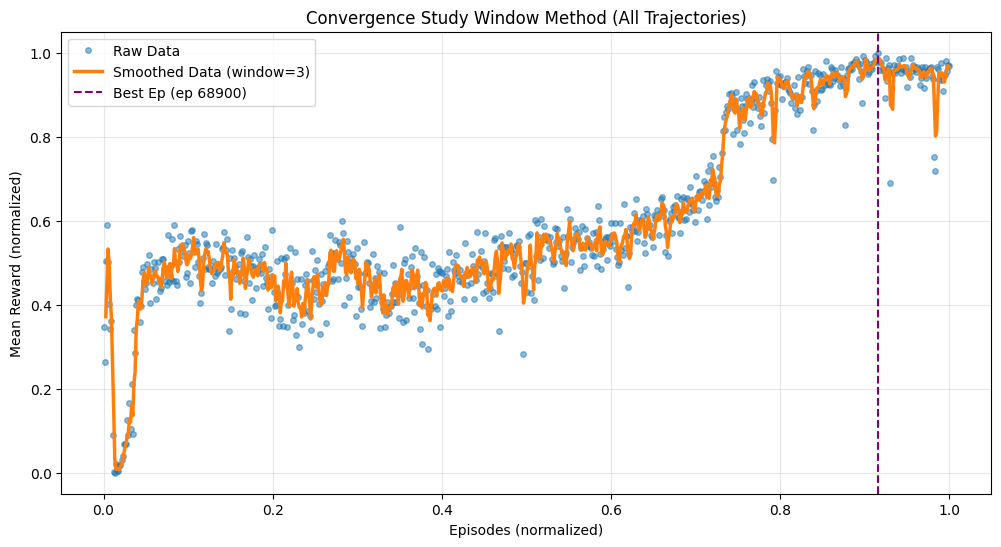

In [ ]:
# Compute convergence points using exponential model fitting
(convergence_step_cross_mean_seen, 
 reward_at_convergence_cross_mean_seen) = get_convergence_point(
    data=df_mean_seen, 
    type="mean_reward_seen",
    window_fraction=0.07,
    convergence_threshold=0.071,
    plot_label="Convergence Study Window Method (Seen Trajectories)",
    best_ep = best_ep_seen
)

(convergence_step_cross_mean_unseen, 
 reward_at_convergence_cross_mean_unseen) = get_convergence_point(
    data=df_mean_unseen, 
    type="mean_reward_unseen",
    window_fraction=0.07,
    convergence_threshold=0.071,
    plot_label="Convergence Study Window Method (Unseen Trajectories)",
    best_ep = best_ep_unseen
)

(convergence_step_cross_mean_all, 
 reward_at_convergence_cross_mean_all) = get_convergence_point(
    data=df_mean_all, 
    type="mean_reward_all",
    window_fraction=0.07,
    convergence_threshold=0.071,
    plot_label="Convergence Study Window Method (All Trajectories)",
    best_ep = best_ep_all
)

In [470]:
# plot a table with the convergence points
print(f"max episodes: {df['episodes'].max()}")
convergence_data = {
    "Trajectory Type": ["Seen", "Unseen", "All"],
    "Convergence Step (Exponential Model Fitting)": [
        convergence_step_cross_mean_seen, 
        convergence_step_cross_mean_unseen, 
        convergence_step_cross_mean_all
    ],
    "Reward at Convergence (Exponential Model Fitting)": [
        reward_at_convergence_cross_mean_seen, 
        reward_at_convergence_cross_mean_unseen, 
        reward_at_convergence_cross_mean_all
    ],
}
convergence_df = pd.DataFrame(convergence_data)
print("\nConvergence Summary:")
print(convergence_df)

max episodes: 75200

Convergence Summary:
  Trajectory Type  Convergence Step (Exponential Model Fitting)  \
0            Seen                                         62500   
1          Unseen                                         75200   
2             All                                         75200   

   Reward at Convergence (Exponential Model Fitting)  
0                                           5.872552  
1                                           4.876526  
2                                           5.603174  


## 9. Convergence Summary Table

Display a summary table with the convergence episode and the corresponding reward value for each trajectory group.

## 10. Reward Distribution at Key Episodes

Box plots showing the reward distribution across all trajectories at two key episodes:

1. **Best episode**: The episode with the highest overall mean reward.
2. **Convergence episode**: The earliest episode at which training is considered to have converged.

This comparison helps assess whether the convergence point already captures most of the achievable performance, or if significant improvement occurs after convergence.

/tmp/ipykernel_7889/2020100527.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rewards_trajs_convergence["rewards"].tolist(),


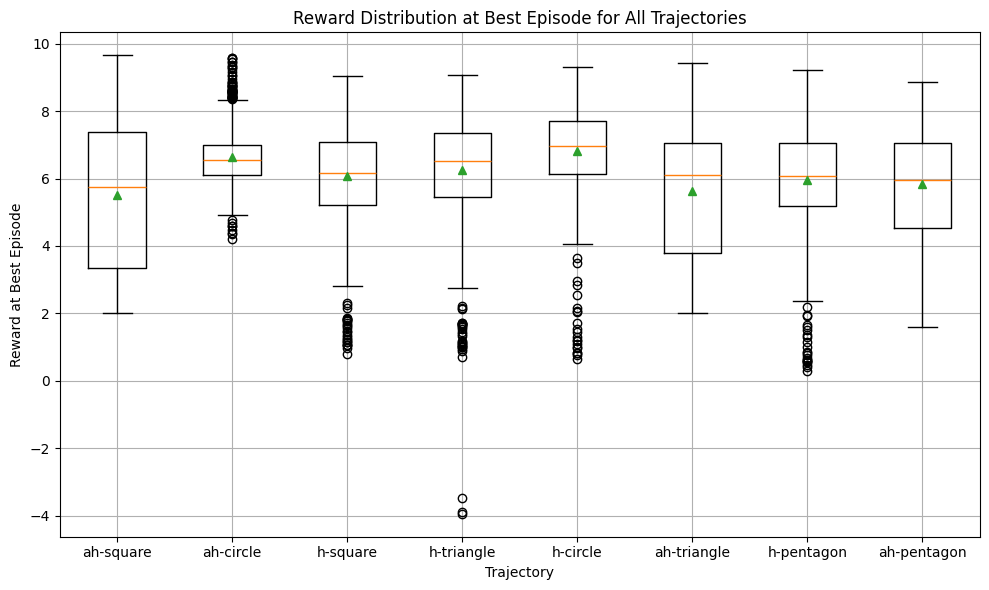

/tmp/ipykernel_7889/2020100527.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rewards_trajs_convergence["rewards"].tolist(),


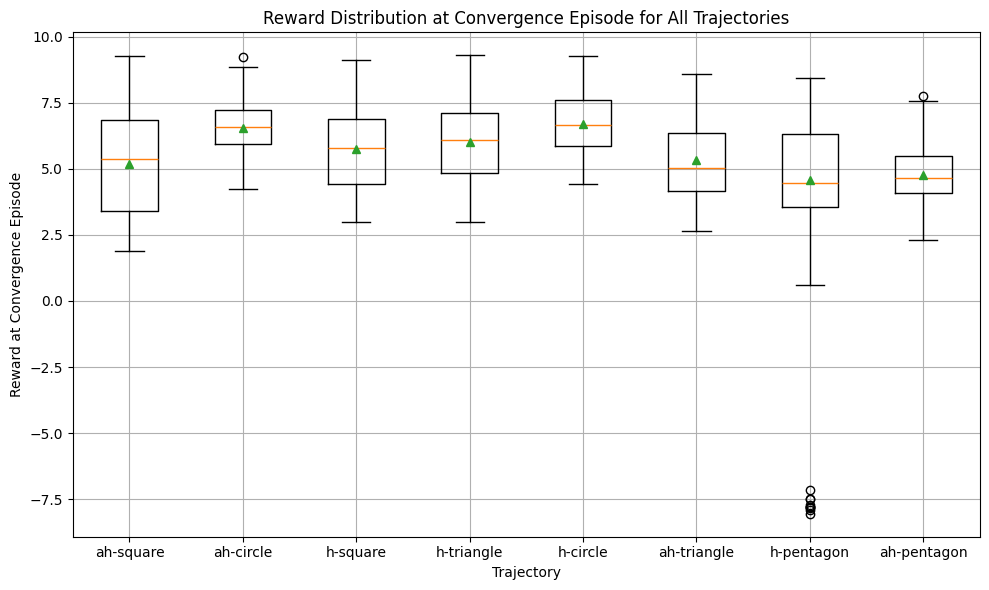

In [ ]:

# Get convergence point for all trajectories using moving average method and plot the boxplot for all trajectories rewards
rewards_trajs_convergence = df[df["episodes"]==best_ep_all][["trajectory", "rewards"]]
# remove the first 3 rewards to avoid initial noise
rewards_trajs_convergence["rewards"] = rewards_trajs_convergence["rewards"].apply(lambda x: x[3:])
# plot boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(rewards_trajs_convergence["rewards"].tolist(), 
            labels=rewards_trajs_convergence["trajectory"].tolist(), 
            showmeans=True)
plt.xlabel("Trajectory")
plt.ylabel("Reward at Best Episode")
plt.title("Reward Distribution at Best Episode for All Trajectories")
plt.grid(True)
plt.tight_layout()
plt.show()


# Same plot but with convergence episode
rewards_trajs_convergence = df[df["episodes"]==convergence_step_cross_mean_all][["trajectory", "rewards"]]
# remove the first 3 rewards to avoid initial noise
rewards_trajs_convergence["rewards"] = rewards_trajs_convergence["rewards"].apply(lambda x: x[3:])
# plot boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(rewards_trajs_convergence["rewards"].tolist(),
            labels=rewards_trajs_convergence["trajectory"].tolist(), 
            showmeans=True)
plt.xlabel("Trajectory")
plt.ylabel("Reward at Convergence Episode")
plt.title("Reward Distribution at Convergence Episode for All Trajectories")
plt.grid(True)
plt.tight_layout()
plt.show()
